In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded!") 

Libraries loaded!


In [3]:
import pandas as pd

# Load the main education data (skip metadata rows)
df = pd.read_csv("API_SE.PRM.NENR_DS2_en_csv_v2_30686.csv", skiprows=4)

# Show first 5 rows
df.head()


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Unnamed: 69
0,Aruba,ABW,"School enrollment, primary (% net)",SE.PRM.NENR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,"School enrollment, primary (% net)",SE.PRM.NENR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,"School enrollment, primary (% net)",SE.PRM.NENR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,"School enrollment, primary (% net)",SE.PRM.NENR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,"School enrollment, primary (% net)",SE.PRM.NENR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df = df.drop(columns=["Indicator Name", "Indicator Code"])

# Rename for clarity
df = df.rename(columns={"Country Name": "Country", "Country Code": "Code"})

# Filter to a few countries
countries = ["United States", "India", "Nigeria", "Spain", "Brazil"]
df_subset = df[df["Country"].isin(countries)]

# View sample
df_subset.head()



,Country,Code,1960,1961,1962,1963,1964,1965,1966,1967,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Unnamed: 69
29,Brazil,BRA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,95.47144,96.29925,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
70,Spain,ESP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,98.78967,97.27171,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
109,India,IND,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
174,Nigeria,NGA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
251,United States,USA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,95.07325,94.62633,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df_melted = df_subset.melt(id_vars=["Country", "Code"], var_name="Year", value_name="Enrollment")
df_melted = df_melted.dropna()
df_melted["Year"] = pd.to_numeric(df_melted["Year"], errors="coerce")

# Preview
df_melted.head()

,Country,Code,Year,Enrollment
56,Spain,ESP,1971,93.21163
57,India,IND,1971,61.04195
61,Spain,ESP,1972,94.54709
66,Spain,ESP,1973,95.47561
76,Spain,ESP,1975,99.46797


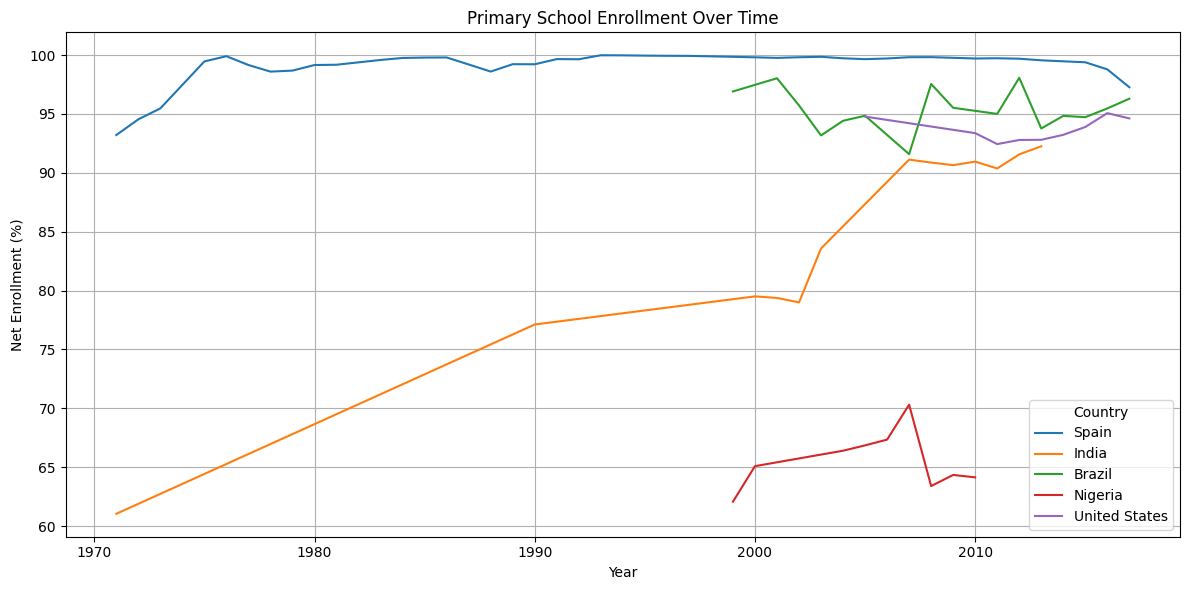

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_melted, x="Year", y="Enrollment", hue="Country")
plt.title("Primary School Enrollment Over Time")
plt.xlabel("Year")
plt.ylabel("Net Enrollment (%)")
plt.grid(True)
plt.tight_layout()
plt.show()


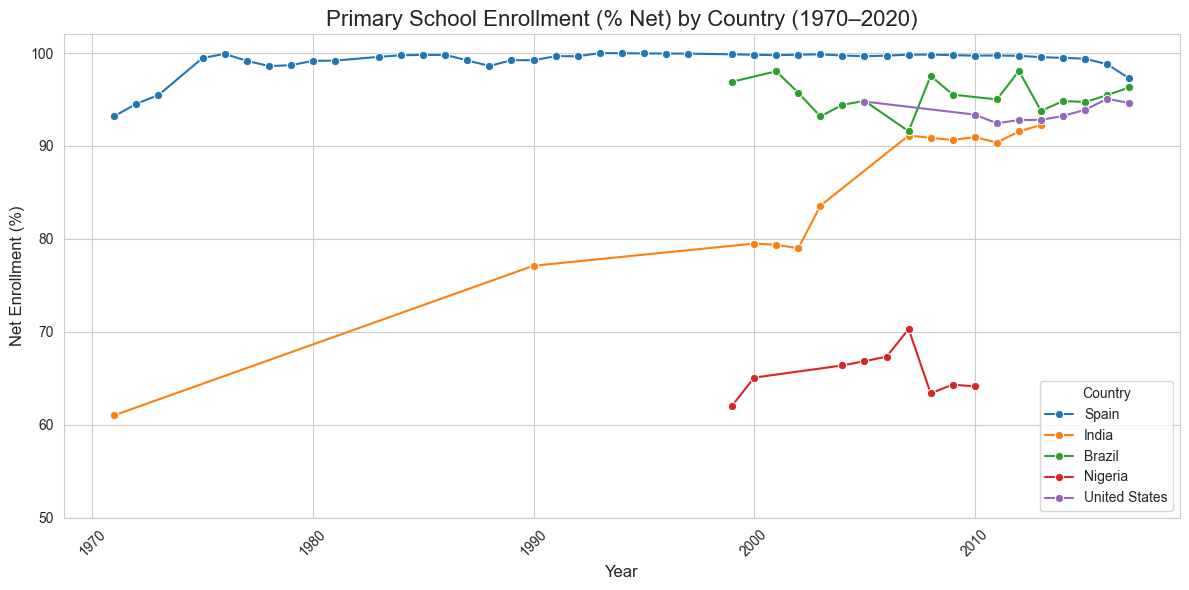

In [8]:
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")  # cleaner background

sns.lineplot(data=df_melted, x="Year", y="Enrollment", hue="Country", marker="o")

plt.title("Primary School Enrollment (% Net) by Country (1970–2020)", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Net Enrollment (%)", fontsize=12)
plt.legend(title="Country", loc='lower right')
plt.xticks(rotation=45)
plt.ylim(50, 102)  # lock in y-axis scale for consistency

plt.tight_layout()
plt.show()

Text(1995, 75, 'Sharp rise in India')

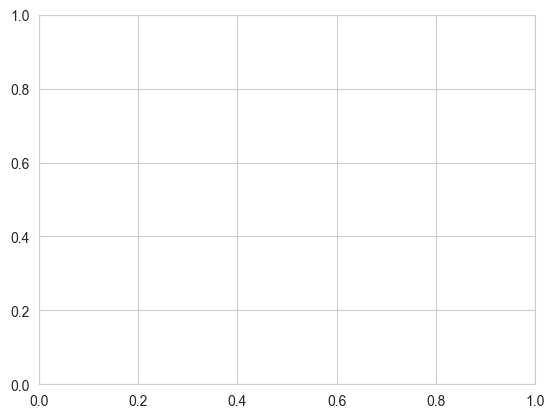

In [13]:
plt.annotate("Sharp rise in India", xy=(2005, 85), xytext=(1995, 75),
             arrowprops=dict(arrowstyle="->", color='black'), fontsize=10) 

Text(1995, 75, 'Sharp rise in India')

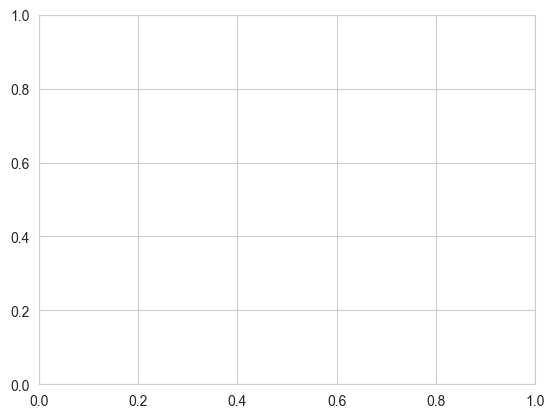

In [12]:
plt.annotate("Sharp rise in India", xy=(2005, 85), xytext=(1995, 75),
             arrowprops=dict(arrowstyle="->", color='black'), fontsize=10) 

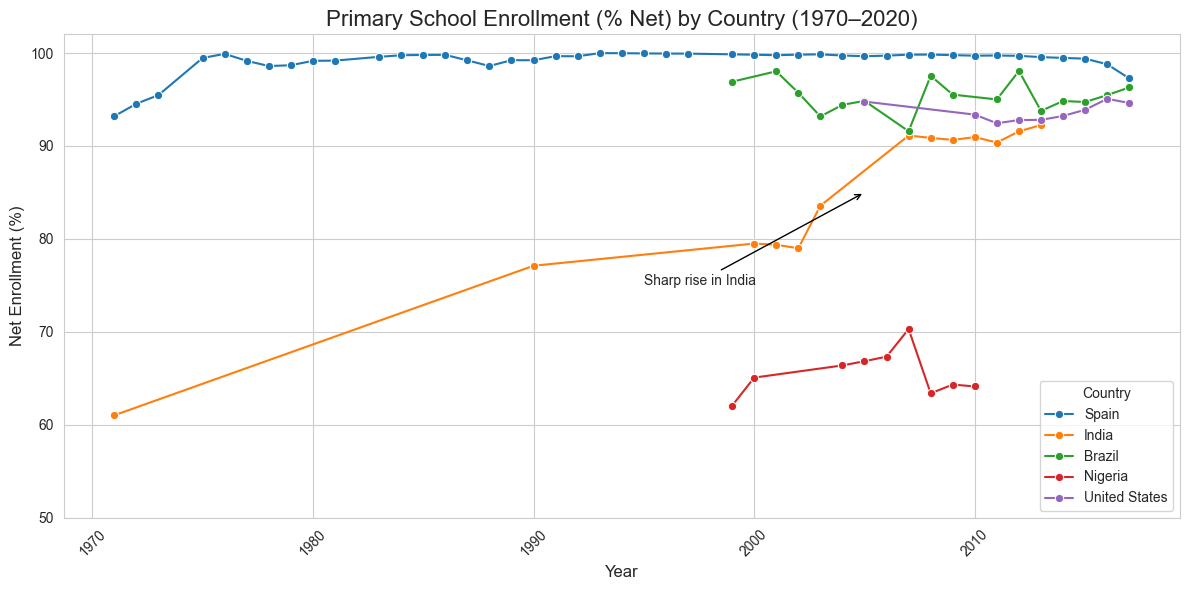

In [14]:
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Plot the data
sns.lineplot(data=df_melted, x="Year", y="Enrollment", hue="Country", marker="o")

# Add title, labels, etc.
plt.title("Primary School Enrollment (% Net) by Country (1970–2020)", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Net Enrollment (%)", fontsize=12)
plt.legend(title="Country", loc='lower right')
plt.xticks(rotation=45)
plt.ylim(50, 102)

# Add annotation (INSIDE the same plot block)
plt.annotate("Sharp rise in India", 
             xy=(2005, 85), 
             xytext=(1995, 75),
             arrowprops=dict(arrowstyle="->", color='black'), 
             fontsize=10)

plt.tight_layout()
plt.show()


In [15]:
plt.savefig("education_enrollment_plot.png", dpi=300)


<Figure size 640x480 with 0 Axes>

In [16]:
# Detect nulls
df.isnull().sum().sort_values(ascending=False).head(10)


1961    266
1960    266
1963    266
1962    266
2020    266
2021    266
1964    266
1965    266
1966    266
1967    266
dtype: int64

C:\Users\krist\AppData\Local\Temp\ipykernel_11036\3623157217.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_latest, x='Enrollment', y='Country', palette='viridis')


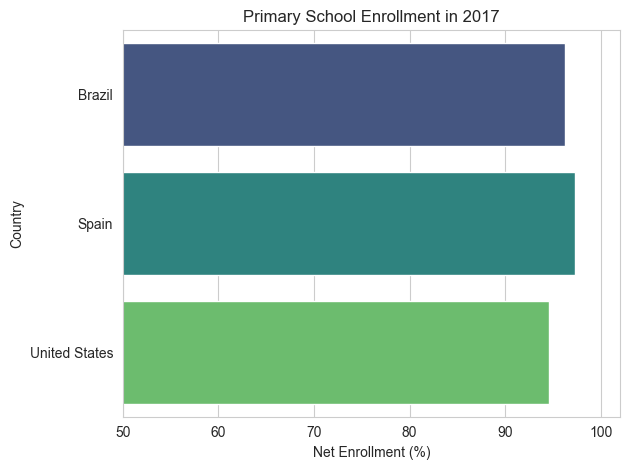

In [17]:
latest_year = df_melted['Year'].max()
df_latest = df_melted[df_melted['Year'] == latest_year]

sns.barplot(data=df_latest, x='Enrollment', y='Country', palette='viridis')
plt.title(f'Primary School Enrollment in {latest_year}')
plt.xlabel('Net Enrollment (%)')
plt.ylabel('Country')
plt.xlim(50, 102)
plt.tight_layout()
plt.show()
